In [2]:

import os, random, datetime, pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#from google.colab import drive
#drive.mount('/content/drive')

#!cp -r "/content/drive/MyDrive/TRAIN_CASIA/CASIA2_split_F" "/content/casia2_split"

In [3]:
def get_srm_kernels():
    import numpy as _np
    k1 = _np.array([[0,0,0],[0,1,-1],[0,0,0]], dtype=_np.float32)
    k2 = _np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=_np.float32)
    k3 = _np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=_np.float32)
    return _np.stack([k1,k2,k3], axis=0)


In [4]:
class InitialTraceExtractor(layers.Layer):
    def __init__(self, out_channels=32, **kwargs):
        super().__init__(**kwargs)
        self.out_channels = out_channels
        self.conv1 = layers.Conv2D(32, 3, padding='same', activation=None)
        self.bn1 = layers.BatchNormalization()
        self.act1 = layers.Activation('relu')
        self.conv2 = layers.Conv2D(32, 3, padding='same', activation=None)
        self.bn2 = layers.BatchNormalization()
        self.act2 = layers.Activation('relu')
    def build(self, input_shape):
        self.srm = get_srm_kernels()
        super().build(input_shape)
    def call(self, x):
        kern = tf.constant(self.srm, dtype=tf.float32)
        ksize = kern.shape[1]
        depth_multiplier = kern.shape[0]
        in_ch = tf.shape(x)[-1]

        k = tf.reshape(kern, (ksize,ksize,1,depth_multiplier))
        k = tf.tile(k, [1,1,in_ch,1])

        x = tf.nn.depthwise_conv2d(x, k, strides=[1,1,1,1], padding='SAME')


        x = x / 10.0

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        return x

In [5]:
def create_forgery_model(input_shape=(256,256,3)):
    inp = layers.Input(shape=input_shape)
    t = InitialTraceExtractor()(inp)
    t = layers.Conv2D(32,3,padding='same',activation=None)(t)
    t = layers.BatchNormalization()(t)
    t = layers.Activation('relu')(t)
    t = layers.MaxPool2D(2)(t)

    t = layers.Conv2D(64,3,padding='same',activation=None)(t)
    t = layers.BatchNormalization()(t)
    t = layers.Activation('relu')(t)
    t = layers.MaxPool2D(2)(t)

    t = layers.Conv2D(64,3,padding='same',activation=None)(t)
    t = layers.BatchNormalization()(t)
    t = layers.Activation('relu')(t)
    t = layers.MaxPool2D(2)(t)

    t = layers.Conv2D(128,1,padding='same',activation=None)(t)
    t =layers.BatchNormalization()(t)

    t =layers.Activation('relu')(t)

    avg_pool = layers.GlobalAveragePooling2D()(t)
    max_pool = layers.GlobalMaxPooling2D()(t)
    t = layers.Concatenate()([avg_pool, max_pool])  # Now 256 features
    t = layers.Dense(256, activation=None)(t)
    t = layers.BatchNormalization()(t)
    t = layers.Activation('relu')(t)
    return models.Model(inputs=inp, outputs=t, name="forgery_feature_extractor")


In [6]:
def ClassifyCMove(input_shape=(256,256,3)):
    feat = create_forgery_model(input_shape)
    inp = feat.input
    f = feat.output
    x = layers.Dropout(0.4)(f)
    x = layers.Dense(128, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out, name="ClassifyCMove_SRMonly")
    return model


In [12]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        # Clip to prevent log(0)
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)

        ce = -(y_true * tf.math.log(y_pred) +
               (1 - y_true) * tf.math.log(1 - y_pred))

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        focal_term = (1 - pt) ** gamma

        loss = alpha * focal_term * ce
        return tf.reduce_mean(loss)

    return loss


In [14]:
DATASET_DIR = "/content/casia2_split"
IMG_SIZE = (256,256)
BATCH_SIZE = 16
EPOCHS = 40

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATASET_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATASET_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


Found 7643 files belonging to 2 classes.
Found 1912 files belonging to 2 classes.


In [15]:
def augment_batch(images, labels):
    images = images / 255.0  # Normalize to [0, 1]
    images = tf.image.random_flip_left_right(images)
    images = tf.image.random_brightness(images, 0.06)
    images = tf.image.random_contrast(images, 0.95, 1.05)
    images = tf.clip_by_value(images, 0.0, 1.0)
    return images, labels

def normalize_batch(images, labels):
    images = images / 255.0  # Normalize to [0, 1]
    return images, labels

train_ds = train_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# The validation dataset should also be normalized to [0, 1] for correct model input
val_ds = val_ds.map(normalize_batch, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


In [16]:

model = ClassifyCMove(input_shape=(256,256,3))
try:
    import tensorflow_addons as tfa
    opt = tfa.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5)
except Exception:
    opt = tf.keras.optimizers.Adam(1e-4)

model.compile(
    optimizer=opt,
    loss=binary_focal_loss(gamma =2.0, alpha =0.25),
    metrics=["accuracy", tf.keras.metrics.AUC()]
)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
best_checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath="checkpoints/best_model.weights.h5", save_weights_only=True, save_best_only=True, monitor="val_loss", mode="min")
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback, early_stopping_callback, best_checkpoint, reduce_lr_callback]
)


Epoch 1/40
478/478 ━━━━━━━━━━━━━━━━━━━━ 86s 139ms/step - accuracy: 0.5417 - auc: 0.5112 - loss: 0.0754 - val_accuracy: 0.6695 - val_auc: 0.5613 - val_loss: 0.0397 - learning_rate: 1.0000e-04
Epoch 2/40
478/478 ━━━━━━━━━━━━━━━━━━━━ 54s 113ms/step - accuracy: 0.7001 - auc: 0.5400 - loss: 0.0520 - val_accuracy: 0.7578 - val_auc: 0.5853 - val_loss: 0.0355 - learning_rate: 1.0000e-04
Epoch 3/40
478/478 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7142 - auc: 0.5504 - loss: 0.0476 - val_accuracy: 0.7829 - val_auc: 0.6025 - val_loss: 0.0355 - learning_rate: 1.0000e-04
Epoch 4/40
478/478 ━━━━━━━━━━━━━━━━━━━━ 55s 115ms/step - accuracy: 0.7159 - auc: 0.5563 - loss: 0.0448 - val_accuracy: 0.7735 - val_auc: 0.6647 - val_loss: 0.0324 - learning_rate: 1.0000e-04
Epoch 5/40
478/478 ━━━━━━━━━━━━━━━━━━━━ 55s 115ms/step - accuracy: 0.7240 - auc: 0.5711 - loss: 0.0432 - val_accuracy: 0.7829 - val_auc: 0.6722 - val_loss: 0.0322 - learning_rate: 1.0000e-04
Epoch 6/40
478/478 ━━━━━━━━━━━━━━━━━━━━ 84s 1

In [17]:
y_true = []
y_pred = []

for batch, labels in val_ds:
    preds = model.predict(batch)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds > 0.5).astype("int32").flatten())

y_true_list = [int(v) for v in y_true]
y_pred_list = [int(v) for v in y_pred]

f1 = f1_score(y_true_list, y_pred_list)
acc = accuracy_score(y_true_list, y_pred_list)
cm  = confusion_matrix(y_true_list, y_pred_list)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

results = {
    "history": history.history,
    "f1_score": f1,
    "accuracy": acc,
    "confusion_matrix": cm.tolist() # Convert numpy array to list for JSON compatibility
}

with open("/content/training_results.pkl", "wb") as f:
    pickle.dump(results, f)

model.save("/content/IMD_final_SRMonly.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━

Accuracy: 0.805439330543933
F1 Score: 0.4608695652173913
Confusion Matrix:
 [[1381  118]
 [ 254  159]]


In [18]:
# Check validation data
for images, labels in val_ds.take(1):
    print(f"Val batch shape: {images.shape}")
    print(f"Val image range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")
    print(f"Val labels: {labels.numpy().flatten()[:10]}")

    # Test model on this batch
    preds = model(images, training=False)
    print(f"Predictions: {preds.numpy().flatten()[:10]}")
    print(f"Pred range: [{tf.reduce_min(preds):.3f}, {tf.reduce_max(preds):.3f}]")

    # Check trace extractor output
    trace_extractor = None
    for layer in model.layers:
        if hasattr(layer, 'layers'):
            for sublayer in layer.layers:
                if isinstance(sublayer, InitialTraceExtractor):
                    trace_extractor = sublayer
                    break

    if trace_extractor:
        # Ensure the input to the trace extractor is also normalized
        trace_out = trace_extractor(images[0:1])
        print(f"\nTrace output range: [{tf.reduce_min(trace_out):.3f}, {tf.reduce_max(trace_out):.3f}]")
        print(f"Trace mean: {tf.reduce_mean(trace_out):.3f}")

Val batch shape: (16, 256, 256, 3)
Val image range: [0.000, 1.000]
Val labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predictions: [0.4295316  0.16150323 0.19750917 0.22804822 0.25194025 0.28515512
 0.38846317 0.23541799 0.15832108 0.45914355]
Pred range: [0.158, 0.545]


UnpicklingError: invalid load key, 'H'.

In [14]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score, accuracy_score
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


In [16]:
model = ClassifyCMove(input_shape=(256,256,3))

model.load_weights("best_model.weights.h5")

print("Weights loaded successfully.")
model.summary()


Weights loaded successfully.


Model: "ClassifyCMove_SRMonly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ initial_trace_extractor       │ (None, 256, 256, 32)      │          12,128 │ input_layer[0][0]          │
│ (InitialTraceExtractor)       │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 256, 256, 32)      │           9,248 │ initial_trace_extractor[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 256, 256, 32)      │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 256, 256, 32)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 32)      │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 128, 128, 64)      │             256 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 128, 128, 64)      │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 64)        │               0 │ activation_3[0][0]         │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 64)        │          36,928 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 64, 64, 64)        │             256 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_4 (Activation)     │ (None, 64, 64, 64)        │               0 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 32, 32, 64)        │               0 │ activation_4[0][0]         │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 186,625 (729.00 KB)

 Trainable params: 185,153 (723.25 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [20]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)

TEST_DIR = r"C:\Users\NEW\ArnavDS\ManNet\test"
WEIGHTS_PATH = "best_model.weights.h5"
SAVE_DIR = "test_results_COLUMBIA"

os.makedirs(SAVE_DIR, exist_ok=True)

model = ClassifyCMove(input_shape=(256,256,3))
model.load_weights(WEIGHTS_PATH)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=(256,256),
    batch_size=32,
    shuffle=False,
    label_mode="binary"
)

y_true_list = []
y_pred_probs = []

for batch, labels in test_ds:
    preds = model.predict(batch)
    y_true_list.extend(labels.numpy().reshape(-1))
    y_pred_probs.extend(preds.reshape(-1))

# convert probabilities → 0/1 labels
y_pred_list = [1 if p >= 0.5 else 0 for p in y_pred_probs]

acc = accuracy_score(y_true_list, y_pred_list)
f1 = f1_score(y_true_list, y_pred_list)
cm  = confusion_matrix(y_true_list, y_pred_list)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


Found 366 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
Accuracy: 0.5
F1 Score: 0.6666666666666666
Confusion Matrix:
 [[  0 183]
 [  0 183]]


In [22]:

y_true = np.asarray(y_true).reshape(-1)
y_pred_probs = np.asarray(y_pred_probs).reshape(-1)
y_pred = (y_pred_probs > 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_pred_probs)
cm   = confusion_matrix(y_true, y_pred)

txt_path = os.path.join(SAVE_DIR, "metrics_report_COLUMBIA.txt")
with open(txt_path, "w") as f:
    f.write("=== TEST RESULTS ===\n")
    f.write(f"Timestamp: {datetime.now()}\n\n")
    f.write(f"Accuracy : {acc:.4f}\n")
    f.write(f"F1 Score : {f1:.4f}\n")
    f.write(f"Precision: {prec:.4f}\n")
    f.write(f"Recall   : {rec:.4f}\n")
    f.write(f"AUC      : {auc:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm) + "\n")

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(SAVE_DIR, "ROC_curve.png"))
plt.close()

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"))
plt.close()

prec_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall_curve, prec_curve)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(SAVE_DIR, "precision_recall_curve.png"))
plt.close()

plt.figure(figsize=(6,5))
plt.hist(y_pred_probs[y_true==0], bins=30, alpha=0.5, label="Authentic")
plt.hist(y_pred_probs[y_true==1], bins=30, alpha=0.5, label="Forged")
plt.title("Prediction Confidence Distribution")
plt.xlabel("Model Probability")
plt.ylabel("Count")
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "prediction_histogram.png"))
plt.close()

print("All results saved in:", SAVE_DIR)


All results saved in: test_results_COLUMBIA


NameError: name 'train_loss' is not defined

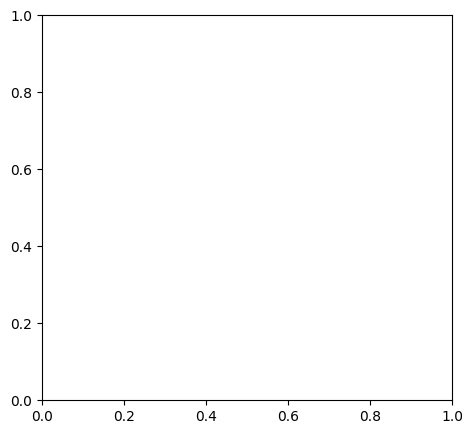

In [1]:
import matplotlib.pyplot as plt

# --- Helper: Safe plot ---
def safe_plot(values, label):
    if values is not None and len(values) > 0:
        plt.plot(values, label=label)

plt.figure(figsize=(18,5))

# -------------------------------------------------
# LOSS
# -------------------------------------------------
plt.subplot(1,3,1)
safe_plot(train_loss, "Train Loss")
safe_plot(val_loss, "Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -------------------------------------------------
# ACCURACY
# -------------------------------------------------
plt.subplot(1,3,2)
safe_plot(train_acc, "Train Acc")
safe_plot(val_acc, "Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# -------------------------------------------------
# AUC
# -------------------------------------------------
plt.subplot(1,3,3)
safe_plot(train_auc, "Train AUC")
safe_plot(val_auc, "Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [6]:
import sys; print(sys.prefix)



C:\Users\NEW\OneDrive\Desktop\Documents\c programs\minorproj\mannet
